## Classical clustering - performance evaluation 1

In [1]:
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ML").master("local[*]").getOrCreate()
spark.conf.set("spark.sql.ansi.enabled", False)

A couple of experiments with features were carried out in this notebook, so far final and the best result corresponding to the setup described below, which is not significanly different from the experiment 0:

One-hot of categorical variables, aggregation of countries by region, year contains only one value, month 5, so those will be dropped. Day number in this experiment will ignored, and Price will be whitened, after we will apply PCA.

In [2]:
from utils.ml import prepare_data_pipeline, evaluate_clustering_model, data_dir
df_raw = spark.read.csv(data_dir, inferSchema=True, header=True, sep=";")
df, pipeline = prepare_data_pipeline(df_raw)

+-------+-------------+------+--------+-----------------+-----+-------+----+------------+------------+
|country|main_category|colour|location|model photography|price|price 2|page|model_letter|model_number|
+-------+-------------+------+--------+-----------------+-----+-------+----+------------+------------+
|      0|            1|     1|       5|                1|   28|      2|   1|           A|          13|
|      0|            1|     1|       6|                1|   33|      2|   1|           A|          16|
|      0|            2|    10|       2|                1|   52|      1|   1|           B|           4|
|      0|            2|     6|       6|                2|   38|      2|   1|           B|          17|
|      0|            2|     4|       3|                2|   52|      1|   1|           B|           8|
+-------+-------------+------+--------+-----------------+-----+-------+----+------------+------------+
only showing top 5 rows



## Evaluation

In [3]:
n_components = [30, 20, 15]
results = {"K-Means": [], "Bisecting KMeans": [], "GMM": []}

In [4]:
from pyspark.ml.clustering import BisectingKMeans, KMeans, GaussianMixture
import matplotlib.pyplot as plt
pca = pipeline.getStages()[-1]
for n in n_components:
    pca.setK(n)
    fitted = pipeline.fit(df)
    print("Explained Variance:", sum(fitted.stages[-1].explainedVariance))
    X = fitted.transform(df)
    results["K-Means"].append(evaluate_clustering_model(KMeans(maxIter=30), X, range(2, 21)))
    results["Bisecting KMeans"].append(evaluate_clustering_model(BisectingKMeans(maxIter=50), X, range(2, 21)))
    results["GMM"].append(evaluate_clustering_model(GaussianMixture(), X, range(2, 21)))


Explained Variance: 0.9018475583353052
Explained Variance: 0.8412174207950736
Explained Variance: 0.7901165496638318


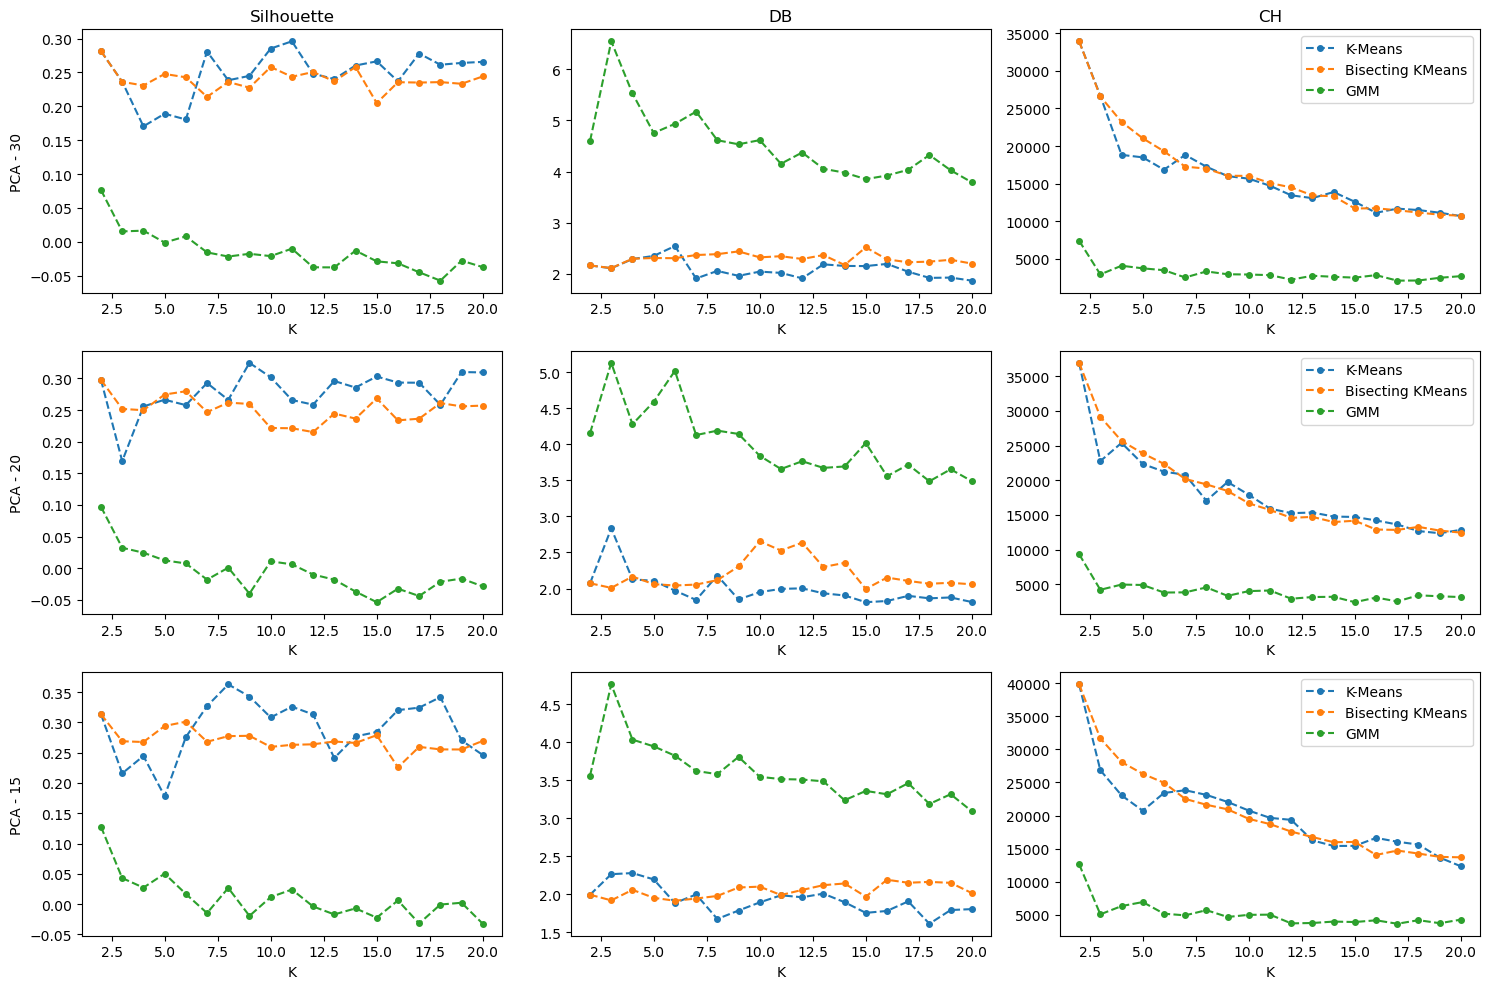

In [5]:
fig, ax = plt.subplots(3, 3, figsize=(15, 10), sharex=False)
models = list(results.keys())
scores = ["Silhouette", "DB", "CH"]
for r in range(3):
    for m in models:
        ax[r, 0].plot(results[m][r]["N_K"], results[m][r]["silouhette"], label= m, linestyle = "--", marker = "o", markersize = 4)
        ax[r, 1].plot(results[m][r]["N_K"], results[m][r]["davies_bouldin"], label= m, linestyle = "--", marker = "o", markersize = 4)
        ax[r, 2].plot(results[m][r]["N_K"], results[m][r]["calinski_harabasz"], label= m, linestyle = "--", marker = "o", markersize = 4)
    for c in range(3):
        ax[r, c].set_xlabel("K")
        if r == 0:
            ax[r, c].set_title(scores[c])
        if c == 0:
            ax[r, c].set_ylabel(f"PCA - {n_components[r]}")
        if c == 2:
            ax[r, c].legend()
plt.tight_layout()
plt.show()

In [6]:
import json
with open('result.json', 'w') as fp:
    json.dump(results, fp)


## Conclusion

### K-Means

* Silhouette: **0.30–0.36  K > 6 (best overall, peak around K ≈ 8)**
* Davies–Bouldin: **~2 and lower**
* Calinski–Harabasz: **high (approx. 20k–40k)**

### Bisecting K-Means

* Silhouette: **0.22–0.30 (worse or similar, better for K <= 6)**
* Davies–Bouldin: **1.9–2.5 (worse than K-Means, K > 6)**
* Calinski–Harabasz: **lower than K-Means or similar for small K**

### GMM (Gaussian Mixture Model)

* Silhouette: **around 0.0 or negative**
* Davies–Bouldin: **3–6**
* Calinski–Harabasz: **~5k**


Based on the clustering evaluation metrics, K-Means outperforms the other models is this setup too, especially when the number of clusters is greater than ~6. In this run, the best performance is observed in the third configuration, with a peak around K = 8, where the silhouette score reaches its highest value (~0.36). This indicates very strong cluster separation, while the low Davies–Bouldin values confirm compact and well-defined clusters. The high Calinski–Harabasz scores further support the presence of a strong clustering structure.

Bisecting K-Means shows reasonably good performance for K <= 6, but becomes less competitive as K increases, remaining slightly worse and less consistent compared to standard K-Means across all metrics.

The GMM again performs poorly, with low or negative silhouette scores and high Davies–Bouldin values, indicating overlapping and poorly separated clusters, likely due to the soft assignment nature of the algorithm.

Overall, the results show that the data is best represented by K-Means clustering, with an optimal number of clusters around 7–10 (approximately K = 8), and using 15 PCA components.